Nama: Aullya Nadine Kuswandi  
Kelas: LA09  
NIM: 2802405125

Link Video:  
https://drive.google.com/drive/folders/1S4vPh3JScX0552lTvaR4N3UPe6aZB88z?usp=drive_link

In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, RobustScaler
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay, make_scorer, precision_score, recall_score, f1_score

from sklearn.utils.class_weight import compute_sample_weight
from imblearn.over_sampling import SMOTE
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.model_selection import StratifiedKFold, cross_validate, RandomizedSearchCV

from collections import Counter
import re

import warnings
warnings.filterwarnings('ignore')

In [59]:
df = pd.read_csv("data_B.csv")
df

,Unnamed: 0,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0,0x15309,CUS_0xaa66,April,NaN,32,841-06-2917,Architect,14995.29,NaN,...,Bad,4593.28,29.968714,3 Years and 2 Months,Yes,60.535964,54.73854091370111,Low_spent_Medium_value_payments,278.586245369556,Poor
1,1,0x8bb6,CUS_0x7d83,January,Dasguptaj,30,227-93-6471,Lawyer,74902.8,6272.900000,...,Bad,2900.49,28.086006,12 Years and 9 Months,Yes,534.751534,52.25901203477476,High_spent_Large_value_payments,280.27945391259857,Poor
2,2,0xe016,CUS_0x71aa,January,Nicholasq,22,632-01-7252,Lawyer,20574.71,1813.559167,...,Bad,2592.78,32.525087,12 Years and 1 Months,Yes,88.759975,77.89308197841973,Low_spent_Large_value_payments,284.70286002007293,Poor
3,3,0xbffb,CUS_0x59b6,February,Scuffhamk,53,315-03-3600,Writer,111090.06,9192.505000,...,Good,575.32,25.360743,27 Years and 6 Months,No,149.079658,436.7372848909153,Low_spent_Medium_value_payments,613.4335567793378,Standard
4,4,0xa96e,CUS_0x36a1,January,Miyoung Kimh,42,286-88-7128,Teacher,19214.965,1730.247083,...,Good,498.81,37.600265,28 Years and 9 Months,No,0.000000,217.7804724472987,!@9#%8,245.2442358860347,Good
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24995,24995,0x1e384,CUS_0xc2cb,July,Kimr,38,523-96-3939,Doctor,22387.125,NaN,...,_,1389.37,26.578408,26 Years and 11 Months,No,0.000000,64.55907623410371,High_spent_Medium_value_payments,353.2002987658962,Good
24996,24996,0x23c9c,CUS_0x412f,March,Joyceg,22,319-02-6843,Manager,29437.24,2645.103333,...,Bad,3377.59,26.974691,4 Years and 3 Months,Yes,116.004348,109.08351963433012,Low_spent_Small_value_payments,329.422465341534,Poor
24997,24997,0x21643,CUS_0x1efd,February,NaN,16,966-55-9007,Teacher,17933.84,1393.486667,...,Standard,1660.5,32.000303,12 Years and 10 Months,NM,48.006051,101.66278268728009,Low_spent_Small_value_payments,279.6798329610804,Standard
24998,24998,0x157df,CUS_0x5db2,June,Paulr,22,929-83-1124,Musician,9400.43,847.369167,...,Bad,4505.63,39.686679,7 Years and 2 Months,Yes,30.338701,50.662519158055105,Low_spent_Medium_value_payments,283.7356961452513,Standard


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                25000 non-null  int64  
 1   ID                        25000 non-null  object 
 2   Customer_ID               25000 non-null  object 
 3   Month                     25000 non-null  object 
 4   Name                      22534 non-null  object 
 5   Age                       25000 non-null  object 
 6   SSN                       25000 non-null  object 
 7   Occupation                25000 non-null  object 
 8   Annual_Income             25000 non-null  object 
 9   Monthly_Inhand_Salary     21244 non-null  float64
 10  Num_Bank_Accounts         25000 non-null  int64  
 11  Num_Credit_Card           25000 non-null  int64  
 12  Interest_Rate             25000 non-null  int64  
 13  Num_of_Loan               25000 non-null  object 
 14  Type_o

Dataset ini terdiri dari 25000 row dan 29 kolom dengan 28 fitur (1 anomali yg Unnamed: 0) dan 1 target klasifikasi, yaitu Credit_Score. Kita juga bisa melihat nama kolom dan tipe data dari setiap kolom di dataset ini. Terlihat ada beberapa kolom yang memiliki mismatch data type, seperti Age, Annual_Income, Num_of_Loan, Num_of_Delayed_Payment, Changed_Credit_Limit, Outstanding_Debt, Amount_invested_monthly, dan Monthly_Balance. Kolom-kolom tersebut harusnya memiliki tipe data integer atau float, tapi terlihat bahwa tipe datanya objek. Oleh karena itu, kita harus cari tahu lebih lanjut untuk mengetahui alasan mengapa variable-variable tersebut memiliki tipe data yang kurang sesuai.

Terdapat kolom Unnamed: 0, ID, dan Customer_ID yang merupakan unique identifier dari data, dan tidak memberikan meaningful information untuk prediksi Credit_Score. Selain itu, kolom Name dan SSN (Social Security Number) merupakan bagian dari identitas customer yang unique untuk setiap customer sehingga tidak memberikan informasi yang bermanfaat untuk prediksi Credit_Score. Oleh karena itu, semua kolom tersebut akan didrop.

In [4]:
df1 = df.drop(columns=['Unnamed: 0','ID','Customer_ID','Name', 'SSN'])
df1.head()

,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,April,32,Architect,14995.29,NaN,7,5,28,5,"Auto Loan, Payday Loan, Mortgage Loan, Payday ...",...,Bad,4593.28,29.968714,3 Years and 2 Months,Yes,60.535964,54.73854091370111,Low_spent_Medium_value_payments,278.586245369556,Poor
1,January,30,Lawyer,74902.8,6272.900000,8,8,33,9,"Auto Loan, Debt Consolidation Loan, Debt Conso...",...,Bad,2900.49,28.086006,12 Years and 9 Months,Yes,534.751534,52.25901203477476,High_spent_Large_value_payments,280.27945391259857,Poor
2,January,22,Lawyer,20574.71,1813.559167,7,9,25,6,"Mortgage Loan, Mortgage Loan, Home Equity Loan...",...,Bad,2592.78,32.525087,12 Years and 1 Months,Yes,88.759975,77.89308197841973,Low_spent_Large_value_payments,284.70286002007293,Poor
3,February,53,Writer,111090.06,9192.505000,0,125,11,3,"Payday Loan, Credit-Builder Loan, and Auto Loan",...,Good,575.32,25.360743,27 Years and 6 Months,No,149.079658,436.7372848909153,Low_spent_Medium_value_payments,613.4335567793378,Standard
4,January,42,Teacher,19214.965,1730.247083,0,4,11,0,NaN,...,Good,498.81,37.600265,28 Years and 9 Months,No,0.000000,217.7804724472987,!@9#%8,245.2442358860347,Good


In [5]:
df1['Credit_Score'].value_counts()

Credit_Score
Standard    13257
Poor         7197
Good         4546
Name: count, dtype: int64

Target sangat tidak balanced (imbalanced)

# Encode Target Column
Credit_Score akan diencode karena dalam mencoba berbagai algoritma atau model, saya menggunakan XGB yang mengharuskan target dalam bentuk angka

In [6]:
df1['Credit_Score'] = df1['Credit_Score'].replace({
    'Poor': 0,
    'Standard': 1,
    'Good': 2
})

# Check Duplicate

In [7]:
sum(df1.duplicated())

0

Tidak ada duplikat pada dataset ini

# Split Dataset

In [8]:
x = df1.drop(columns=['Credit_Score'])
y = df1['Credit_Score']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42, stratify = y)

print("x_train shape: ", x_train.shape)
print("x_test shape: ", x_test.shape)
print("y_train shape: ", y_train.shape)
print("y_test shape: ", y_test.shape)

x_train shape:  (20000, 23)
x_test shape:  (5000, 23)
y_train shape:  (20000,)
y_test shape:  (5000,)


# EDA

In [9]:
x_train.isnull().sum()

Month                          0
Age                            0
Occupation                     0
Annual_Income                  0
Monthly_Inhand_Salary       2994
Num_Bank_Accounts              0
Num_Credit_Card                0
Interest_Rate                  0
Num_of_Loan                    0
Type_of_Loan                2295
Delay_from_due_date            0
Num_of_Delayed_Payment      1404
Changed_Credit_Limit           0
Num_Credit_Inquiries         392
Credit_Mix                     0
Outstanding_Debt               0
Credit_Utilization_Ratio       0
Credit_History_Age          1832
Payment_of_Min_Amount          0
Total_EMI_per_month            0
Amount_invested_monthly      862
Payment_Behaviour              0
Monthly_Balance              222
dtype: int64

In [10]:
x_test.isnull().sum()

Month                         0
Age                           0
Occupation                    0
Annual_Income                 0
Monthly_Inhand_Salary       762
Num_Bank_Accounts             0
Num_Credit_Card               0
Interest_Rate                 0
Num_of_Loan                   0
Type_of_Loan                553
Delay_from_due_date           0
Num_of_Delayed_Payment      329
Changed_Credit_Limit          0
Num_Credit_Inquiries         98
Credit_Mix                    0
Outstanding_Debt              0
Credit_Utilization_Ratio      0
Credit_History_Age          460
Payment_of_Min_Amount         0
Total_EMI_per_month           0
Amount_invested_monthly     198
Payment_Behaviour             0
Monthly_Balance              79
dtype: int64

Terdapat missing value di 7 kolom, baik di data train maupun test.

## Inconsistent Value

In [11]:
cat_col = [c for c in x_train.columns if x_train[c].dtype == 'object']
for c in cat_col:
    print(f"Total unique values in {c}: {x_train[c].nunique()}")
    print(x_train[c].value_counts(), "\n")

Total unique values in Month: 8
Month
March       2550
July        2541
August      2537
January     2520
April       2510
May         2458
June        2447
February    2437
Name: count, dtype: int64 

Total unique values in Age: 464
Age
28       605
31       575
34       553
38       552
39       550
        ... 
8216       1
6452       1
1512       1
7925       1
3055_      1
Name: count, Length: 464, dtype: int64 

Total unique values in Occupation: 16
Occupation
_______          1409
Accountant       1319
Lawyer           1307
Architect        1291
Engineer         1269
Scientist        1263
Media_Manager    1251
Writer           1242
Entrepreneur     1242
Doctor           1235
Mechanic         1230
Journalist       1201
Developer        1198
Manager          1192
Teacher          1188
Musician         1163
Name: count, dtype: int64 

Total unique values in Annual_Income: 11512
Annual_Income
15910.33             7
10667.73             6
35739.7              6
46874.85000000001    6

Unknown category ditemukan pada beberapa kolom, seperti '!@9#%8' pada Payment_Behaviour, '-' pada Credit_Mix, '_______' pada Occupation

Dari hasil value_counts(), kita juga bisa melihat alasan mengapa beberapa kolom yang seharusnya bertipe numerik (seperti Annual_Income, Outstanding_Debt, dan lainnya) memiliki tipe data object. Hal ini terjadi karena di dalam kolom tersebut terdapat karakter non-angka (selain titik sebagai penanda desimal dan - untuk negatif), misalnya karakter '_'. Oleh karena itu, sebelum mengubah kolom-kolom tersebut menjadi tipe numerik, kita harus membersihkan karakter yang tidak valid dulu.

Sebagai antisipasi, saya akan mengecek kembali setiap kolom yang seharusnya bertipe numerik, untuk melihat apakah masih ada karakter selain angka, tanda desimal, dan tanda negatif. Hal ini dilakukan agar proses konversi tipe data bisa dilakukan dengan benar.

In [12]:
potential = ['Age', 'Annual_Income', 'Num_of_Loan', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Outstanding_Debt', 'Amount_invested_monthly', 'Monthly_Balance']
pattern = r'[^0-9.-]'

print("Data Train")
for c in potential:
    print(f"Column {c}:")
    mask = x_train[c].astype(str).str.contains(pattern, na=False)
    print(x_train[mask][c].unique(), "\n")

Data Train
Column Age:
['22_' '23_' '42_' '44_' '27_' '21_' '45_' '19_' '33_' '36_' '35_' '38_'
 '50_' '26_' '41_' '51_' '30_' '29_' '24_' '31_' '39_' '902_' '18_' '25_'
 '54_' '15_' '17_' '32_' '47_' '20_' '49_' '56_' '52_' '40_' '55_' '37_'
 '34_' '53_' '48_' '28_' '14_' '8523_' '46_' '43_' '16_' '1843_' '4301_'
 '2111_' '7122_' '2463_' '733_' '844_' '1591_' '6556_' '3564_' '8348_'
 '2329_' '1070_' '3055_'] 

Column Annual_Income:
['33381.68_' '49217.68_' '18622.57_' ... '20958.75_' '25757.56_'
 '88859.37_'] 

Column Num_of_Loan:
['6_' '5_' '4_' '0_' '8_' '1_' '7_' '2_' '9_' '3_' '359_' '1320_' '1171_'] 

Column Num_of_Delayed_Payment:
['17_' nan '20_' '14_' '13_' '11_' '16_' '23_' '8_' '15_' '7_' '9_' '25_'
 '3840_' '0_' '3_' '4_' '10_' '5_' '18_' '12_' '-1_' '6_' '1_' '21_' '2_'
 '-2_' '22_' '24_' '19_' '-3_' '27_'] 

Column Changed_Credit_Limit:
['_'] 

Column Outstanding_Debt:
['78.41_' '839.1_' '373.74_' '2598.21_' '598.76_' '53.79_' '4787.13_'
 '52.07_' '1420.04_' '4733.81_' '1

Selanjutnya kita akan strip atau potong karakter non angka dan yg bukan negatif ataupun titik, lalu mengubah tipe datanya menjadi numerik

In [13]:
for col in potential:
    x_train[col] = (
        x_train[col]
        .astype(str)
        .str.replace(r'[^0-9\.\-]', '', regex=True)
        .str.replace(r'(?<!^)-', '', regex=True)
    )
    x_test[col] = (
        x_test[col]
        .astype(str)
        .str.replace(r'[^0-9\.\-]', '', regex=True)
        .str.replace(r'(?<!^)-', '', regex=True)
    )
    x_train[col] = pd.to_numeric(x_train[col], errors='coerce')
    x_test[col] = pd.to_numeric(x_test[col], errors='coerce')

In [14]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20000 entries, 21283 to 13888
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Month                     20000 non-null  object 
 1   Age                       20000 non-null  int64  
 2   Occupation                20000 non-null  object 
 3   Annual_Income             20000 non-null  float64
 4   Monthly_Inhand_Salary     17006 non-null  float64
 5   Num_Bank_Accounts         20000 non-null  int64  
 6   Num_Credit_Card           20000 non-null  int64  
 7   Interest_Rate             20000 non-null  int64  
 8   Num_of_Loan               20000 non-null  int64  
 9   Type_of_Loan              17705 non-null  object 
 10  Delay_from_due_date       20000 non-null  int64  
 11  Num_of_Delayed_Payment    18596 non-null  float64
 12  Changed_Credit_Limit      19576 non-null  float64
 13  Num_Credit_Inquiries      19608 non-null  float64
 14  Credit_

In [15]:
x_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5000 entries, 9373 to 20470
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Month                     5000 non-null   object 
 1   Age                       5000 non-null   int64  
 2   Occupation                5000 non-null   object 
 3   Annual_Income             5000 non-null   float64
 4   Monthly_Inhand_Salary     4238 non-null   float64
 5   Num_Bank_Accounts         5000 non-null   int64  
 6   Num_Credit_Card           5000 non-null   int64  
 7   Interest_Rate             5000 non-null   int64  
 8   Num_of_Loan               5000 non-null   int64  
 9   Type_of_Loan              4447 non-null   object 
 10  Delay_from_due_date       5000 non-null   int64  
 11  Num_of_Delayed_Payment    4671 non-null   float64
 12  Changed_Credit_Limit      4892 non-null   float64
 13  Num_Credit_Inquiries      4902 non-null   float64
 14  Credit_Mi

Sekarang, tipe datanya sudah sesuai. Selanjutnya, categorical column juga akan dicek untuk melihat inconsistent secara lebih jelas

In [16]:
cat_col2 = [c for c in x_train.columns if x_train[c].dtype == 'object']
for c in cat_col2:
    print(f"Total unique values in {c}: {x_train[c].nunique()}")
    print(x_train[c].unique(), "\n")

Total unique values in Month: 8
['July' 'February' 'May' 'March' 'August' 'June' 'January' 'April'] 

Total unique values in Occupation: 16
['Engineer' 'Developer' 'Teacher' 'Scientist' 'Writer' 'Doctor'
 'Architect' 'Mechanic' 'Musician' 'Media_Manager' 'Manager' '_______'
 'Entrepreneur' 'Accountant' 'Lawyer' 'Journalist'] 

Total unique values in Type_of_Loan: 5350
['Personal Loan, and Home Equity Loan' 'Auto Loan, and Mortgage Loan'
 'Personal Loan, and Payday Loan' ...
 'Debt Consolidation Loan, Personal Loan, Auto Loan, and Student Loan'
 'Payday Loan, Auto Loan, Auto Loan, Personal Loan, Not Specified, Credit-Builder Loan, Credit-Builder Loan, Debt Consolidation Loan, and Student Loan'
 'Home Equity Loan, Mortgage Loan, Personal Loan, Student Loan, Mortgage Loan, Debt Consolidation Loan, Debt Consolidation Loan, Student Loan, and Not Specified'] 

Total unique values in Credit_Mix: 4
['_' 'Bad' 'Standard' 'Good'] 

Total unique values in Credit_History_Age: 404
['24 Years and 1 

Masih terdapat inconsistent di 3 kolom kategorikal:  
a. Occupation terdapat '_______' value  
b. Credit_Mix terdapat '\_' value   
c. Payment_Behaviour terdapat '!@9#%8' value  

Untuk poin-poin di atas, value-value tersebut tidak merepresentasikan valid categories dan hanya sebagai placeholders atau noisy entries. Oleh karena itu, mereka akan dianggap sebagai missing values dan di convert ke NaN sebelum diproses lebih lanjut.

In [17]:
noise = {
    'Occupation': ['_______'],
    'Credit_Mix': ['_'],
    'Payment_Behaviour': ['!@9#%8']
}

for c, val in noise.items():
    x_train[c] = x_train[c].replace(val, np.nan)
    x_test[c] = x_test[c].replace(val, np.nan)

## Pemisahan Kolom Type_of_Loan
Pada kolom Type_of_Loan, datanya berupa multivalues dalam satu cell yang sama. Agar lebih efektif untuk modeling, saya akan bagi menjadi beberapa kolom berdasarkan tipe loan yang ada didalam daftar tersebut. Setiap kolom akan diisi frekuensi dari masing-masing tipe loan. Untuk data test, akan menggunakan kategori yang ada di data train. Hal ini karena data test dianggap sebagai data inference dimana kategorinya menyesuaikan data train

In [18]:
def parse_loan_types(x):
    if pd.isna(x):
        return Counter()
    x = x.replace(' and ', ',')                       
    loans = [l.strip().lower() for l in x.split(',')]
    loans = [l for l in loans if l]                   
    return Counter(loans)                             

def make_loan_freq(s):
    return (s.apply(lambda x: pd.Series(parse_loan_types(x)))
             .fillna(0).astype(int)
             .add_suffix('_freq'))

loan_train = make_loan_freq(x_train['Type_of_Loan'])
LOAN_COLS  = loan_train.columns                                   

loan_test  = (make_loan_freq(x_test['Type_of_Loan'])
              .reindex(columns=LOAN_COLS, fill_value=0))          

x_train = pd.concat([x_train, loan_train], axis=1)
x_test  = pd.concat([x_test,  loan_test],  axis=1)

x_train = x_train.drop(columns='Type_of_Loan')
x_test = x_test.drop(columns='Type_of_Loan')

In [19]:
x_train.head()

,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,...,Monthly_Balance,personal loan_freq,home equity loan_freq,auto loan_freq,mortgage loan_freq,payday loan_freq,not specified_freq,credit-builder loan_freq,student loan_freq,debt consolidation loan_freq
21283,July,31,Engineer,26053.36,2059.113333,8,6,11,2,12,...,325.743596,1,1,0,0,0,0,0,0,0
8621,February,25,Developer,66755.64,5556.970000,6,9,21,2,35,...,412.194992,0,0,1,1,0,0,0,0,0
14925,May,48,Developer,33057.46,2836.788333,4,3,12,2,27,...,440.187380,1,0,0,0,1,0,0,0,0
57,March,19,Teacher,95099.80,NaN,5,5,7,4,8,...,417.719369,0,1,0,0,1,1,1,0,0
5924,February,45,Scientist,33381.68,2482.806667,8,3,8,5,6,...,273.611939,0,0,1,0,1,0,1,1,1


In [20]:
x_test.head()

,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,...,Monthly_Balance,personal loan_freq,home equity loan_freq,auto loan_freq,mortgage loan_freq,payday loan_freq,not specified_freq,credit-builder loan_freq,student loan_freq,debt consolidation loan_freq
9373,June,25,Accountant,54843.69,4438.307500,6,7,32,9,59,...,220.909344,1,0,3,0,1,0,1,1,2
22283,July,38,Media_Manager,15659.24,1469.232332,7,9,15,6,29,...,216.377082,1,0,0,0,1,1,1,2,0
10286,August,23,Writer,90562.83,7299.902500,3,4,1,2,-1,...,647.176707,0,1,0,0,0,0,0,0,1
4767,June,51,Scientist,35516.68,NaN,0,2,6,-100,14,...,372.541156,0,0,1,0,3,0,0,0,0
16695,April,44,Writer,68380.29,5448.357500,4,4,18,3,28,...,496.049391,0,1,1,0,0,0,0,0,1


## Convert Kolom Credit_History_Age
Kolom Credit_History_Age masih dalam bentuk string dimana format ini kurang informatif untuk fitur prediksi. Oleh karena itu, akan diubah ke dalam bentuk numerik yaitu jumlah bulannya agar lebih informatif.

In [21]:
def credit_history_to_months(s):
    if pd.isna(s):
        return np.nan
    m = re.findall(r'(\d+)', str(s))          
    if len(m) >= 2:
        return int(m[0]) * 12 + int(m[1])      
    return np.nan

x_train['Credit_History_Age'] = x_train['Credit_History_Age'].apply(credit_history_to_months)
x_test['Credit_History_Age'] = x_test['Credit_History_Age'].apply(credit_history_to_months)

## Pemisahan Kolom Payment_Behaviour
Jika kita lihat value dari kolom Payment_Behaviour, terlihat bahwa valuenya merupakan gabungan dari Spent Level dan Payment_Value. Oleh karena itu, saya memutuskan untuk memisahkannya menjadi 2 fitur agar model bisa belajar lebih banyak.

In [ ]:
for d in [x_train, x_test]:
    d['Spent_Level'] = d['Payment_Behaviour'].str.extract(r'(Low|High)_spent')[0]
    d['Payment_Value'] = d['Payment_Behaviour'].str.extract(r'spent_(Small|Medium|Large)_value')[0]

x_train = x_train.drop(columns='Payment_Behaviour')
x_test  = x_test.drop(columns='Payment_Behaviour')

## Drop Kolom Turunan
Terdapat kolom Num_of_Loan yang merupakan hasil penjumlahan dari semua tipe loan yang awalnya ada di Type_of_Loan sehingga kolom Num_of_Loan menjadi redundan dan perlu di drop.

In [23]:
x_train = x_train.drop(columns='Num_of_Loan')
x_test = x_test.drop(columns='Num_of_Loan')

## Invalid Value & Outlier in Numeric Column

In [24]:
x_train.dtypes

Month                            object
Age                               int64
Occupation                       object
Annual_Income                   float64
Monthly_Inhand_Salary           float64
Num_Bank_Accounts                 int64
Num_Credit_Card                   int64
Interest_Rate                     int64
Delay_from_due_date               int64
Num_of_Delayed_Payment          float64
Changed_Credit_Limit            float64
Num_Credit_Inquiries            float64
Credit_Mix                       object
Outstanding_Debt                float64
Credit_Utilization_Ratio        float64
Credit_History_Age              float64
Payment_of_Min_Amount            object
Total_EMI_per_month             float64
Amount_invested_monthly         float64
Monthly_Balance                 float64
personal loan_freq                int32
home equity loan_freq             int32
auto loan_freq                    int32
mortgage loan_freq                int32
payday loan_freq                  int32


In [25]:
x_train.loc[:, x_train.columns].describe(exclude = ['object', 'int32'])

,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance
count,20000.00000,2.000000e+04,17006.000000,20000.000000,20000.000000,20000.000000,20000.000000,18596.000000,19576.000000,19608.000000,20000.000000,20000.000000,18168.000000,20000.000000,19138.000000,1.977800e+04
mean,114.14540,1.812475e+05,4212.754421,16.316350,22.199600,71.040250,20.967450,33.724134,10.350230,28.195940,1413.522515,32.307126,221.630559,1311.591110,663.479602,-1.685374e+22
std,708.62565,1.453274e+06,3176.343282,114.141549,128.798794,454.926868,14.778299,245.923985,6.774394,196.725856,1148.428935,5.142583,100.346697,7962.482745,2097.336284,2.370214e+24
min,-500.00000,7.006035e+03,303.645417,-1.000000,0.000000,1.000000,-5.000000,-3.000000,-6.450000,0.000000,0.230000,20.985606,1.000000,0.000000,0.000000,-3.333333e+26
25%,24.00000,1.955616e+04,1632.430000,3.000000,4.000000,8.000000,10.000000,9.000000,5.300000,3.000000,557.035000,28.000206,144.000000,30.306321,76.483074,2.696689e+02
50%,33.00000,3.796316e+04,3130.127500,6.000000,5.000000,13.000000,18.000000,14.000000,9.370000,6.000000,1162.600000,32.337413,220.000000,69.612071,138.700024,3.370593e+02
75%,42.00000,7.332700e+04,5989.025625,7.000000,7.000000,20.000000,28.000000,18.000000,14.760000,9.000000,1917.017500,36.571349,302.000000,160.540513,268.561251,4.724577e+02
max,8666.00000,2.417715e+07,15204.633333,1798.000000,1495.000000,5774.000000,67.000000,4397.000000,35.890000,2587.000000,4998.070000,49.254983,404.000000,82048.000000,10000.000000,1.576289e+03


Semua numeric variables pada dataset ini seharusnya memiliki nilai positif semua, tidak ada yang negatif, kecuali untuk Changed_Credit_Limit and Delay_from_due_date. Changed_Credit_Limit yang bernilai negatif merepresentasikan penurunan customer credit limit dibanding periode sebelumnya. Sedangkan Delay_from_due_date yang bernilai negatif mengindikasikan early payment, yang berarti pembayaran dilakukan sebelum due date.

Diluar Changed_Credit_Limit dan Delay_from_due_date, beberapa numerik variable mengandung negative value yang secara logika tidak valid. Sebagai contoh nilai minimum age -500, dimana hal ini tidak mungkin karena age tidak bisa negatif.

Saat meneliti maximum values, beberapa variable juga menunjukan angka yang tidak realistik. Contohnya Age mencapai maksimum 8666 years dan Num_Bank_Account mencapai 1798. Kedua value ini tentu tidak masuk akal sehingga perlu ditangani dengan diubah menjadi missing value untuk selanjutnya diproses.

### Pengecekan Invalid Value

In [72]:
df[df['Num_Bank_Accounts']>1000]

,Unnamed: 0,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
239,239,0x1b219,CUS_0x480f,April,Lesley Wroughtond,48,557-78-3651,Doctor,22431.61_,1775.300833,...,Good,1450.57,33.583126,17 Years and 2 Months,No,0.000000,110.16628699900002,Low_spent_Medium_value_payments,347.36379633433336,Good
635,635,0x116ef,CUS_0x6da8,February,Caroline Valetkevitchu,21,566-95-6703,Accountant,37607.28,2842.940000,...,Standard,1361.67,29.154710,18 Years and 11 Months,NM,81.816906,170.97373474354038,High_spent_Small_value_payments,291.5033591882078,Standard
807,807,0x12669,CUS_0x51a4,April,Soyoung Kima,21,500-92-8739,Engineer,56390.0,4743.166667,...,Bad,4402.43,35.921255,13 Years and 2 Months,NM,329.398489,78.80349007960443,High_spent_Large_value_payments,306.11468717954085,Poor
811,811,0x18f81,CUS_0x24cc,April,Kate Holtonv,30,574-39-8582,Writer,36186.85,2797.570833,...,Good,761.58,29.669222,29 Years and 6 Months,No,18.309343,99.77773867752406,High_spent_Medium_value_payments,411.6700015879474,Poor
815,815,0xe7d4,CUS_0x11e2,March,Valetkevitchr,34,809-04-1419,_______,44986.55,3689.879167,...,Good,753.21,32.428368,19 Years and 7 Months,No,23.267135,46.691803035309,High_spent_Medium_value_payments,549.0289781541175,Good
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24471,24471,0x21a1e,CUS_0x489b,May,Malonem,31,769-46-3750,Manager,177560.68,NaN,...,Good,376.64,45.996659,24 Years and 1 Months,No,0.000000,297.646647156356,High_spent_Large_value_payments,1393.6256861769773,Poor
24519,24519,0x1862b,CUS_0xc72e,February,Yueo,38,094-54-0952,Lawyer,32125.54,2559.128333,...,_,2557.14,40.215768,5 Years and 11 Months,Yes,59.330922,NaN,High_spent_Small_value_payments,321.7079654671967,Poor
24572,24572,0x14011,CUS_0xbdbf,August,Philipp Halstrickr,41,276-84-5931,Entrepreneur,35124.99,2937.082500,...,Good,384.22_,31.350778,18 Years and 4 Months,No,106.896464,242.56314542003025,Low_spent_Small_value_payments,234.24864073496053,Good
24687,24687,0x2706,CUS_0xc247,January,rian Loveq,44,800-03-6665,Developer,11968.51,1254.375833,...,Standard,685.74,27.670114,24 Years and 9 Months,No,18.074485,36.679505318776606,Low_spent_Large_value_payments,340.683592961646,Standard


In [73]:
df[df['Customer_ID']=='CUS_0x480f'].iloc[:, :18]

,Unnamed: 0,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit
239,239,0x1b219,CUS_0x480f,April,Lesley Wroughtond,48,557-78-3651,Doctor,22431.61_,1775.300833,1128,6,5,0,NaN,3,0,4.86
14770,14770,0x1b21a,CUS_0x480f,May,Lesley Wroughtond,48,557-78-3651,Doctor,22431.61,1775.300833,5,6,5,0,NaN,3,3,2.8600000000000003
16922,16922,0x1b217,CUS_0x480f,February,Lesley Wroughtond,48,557-78-3651,Doctor,22431.61,1775.300833,4,5,5,0,NaN,3,0,4.86


### Outlier

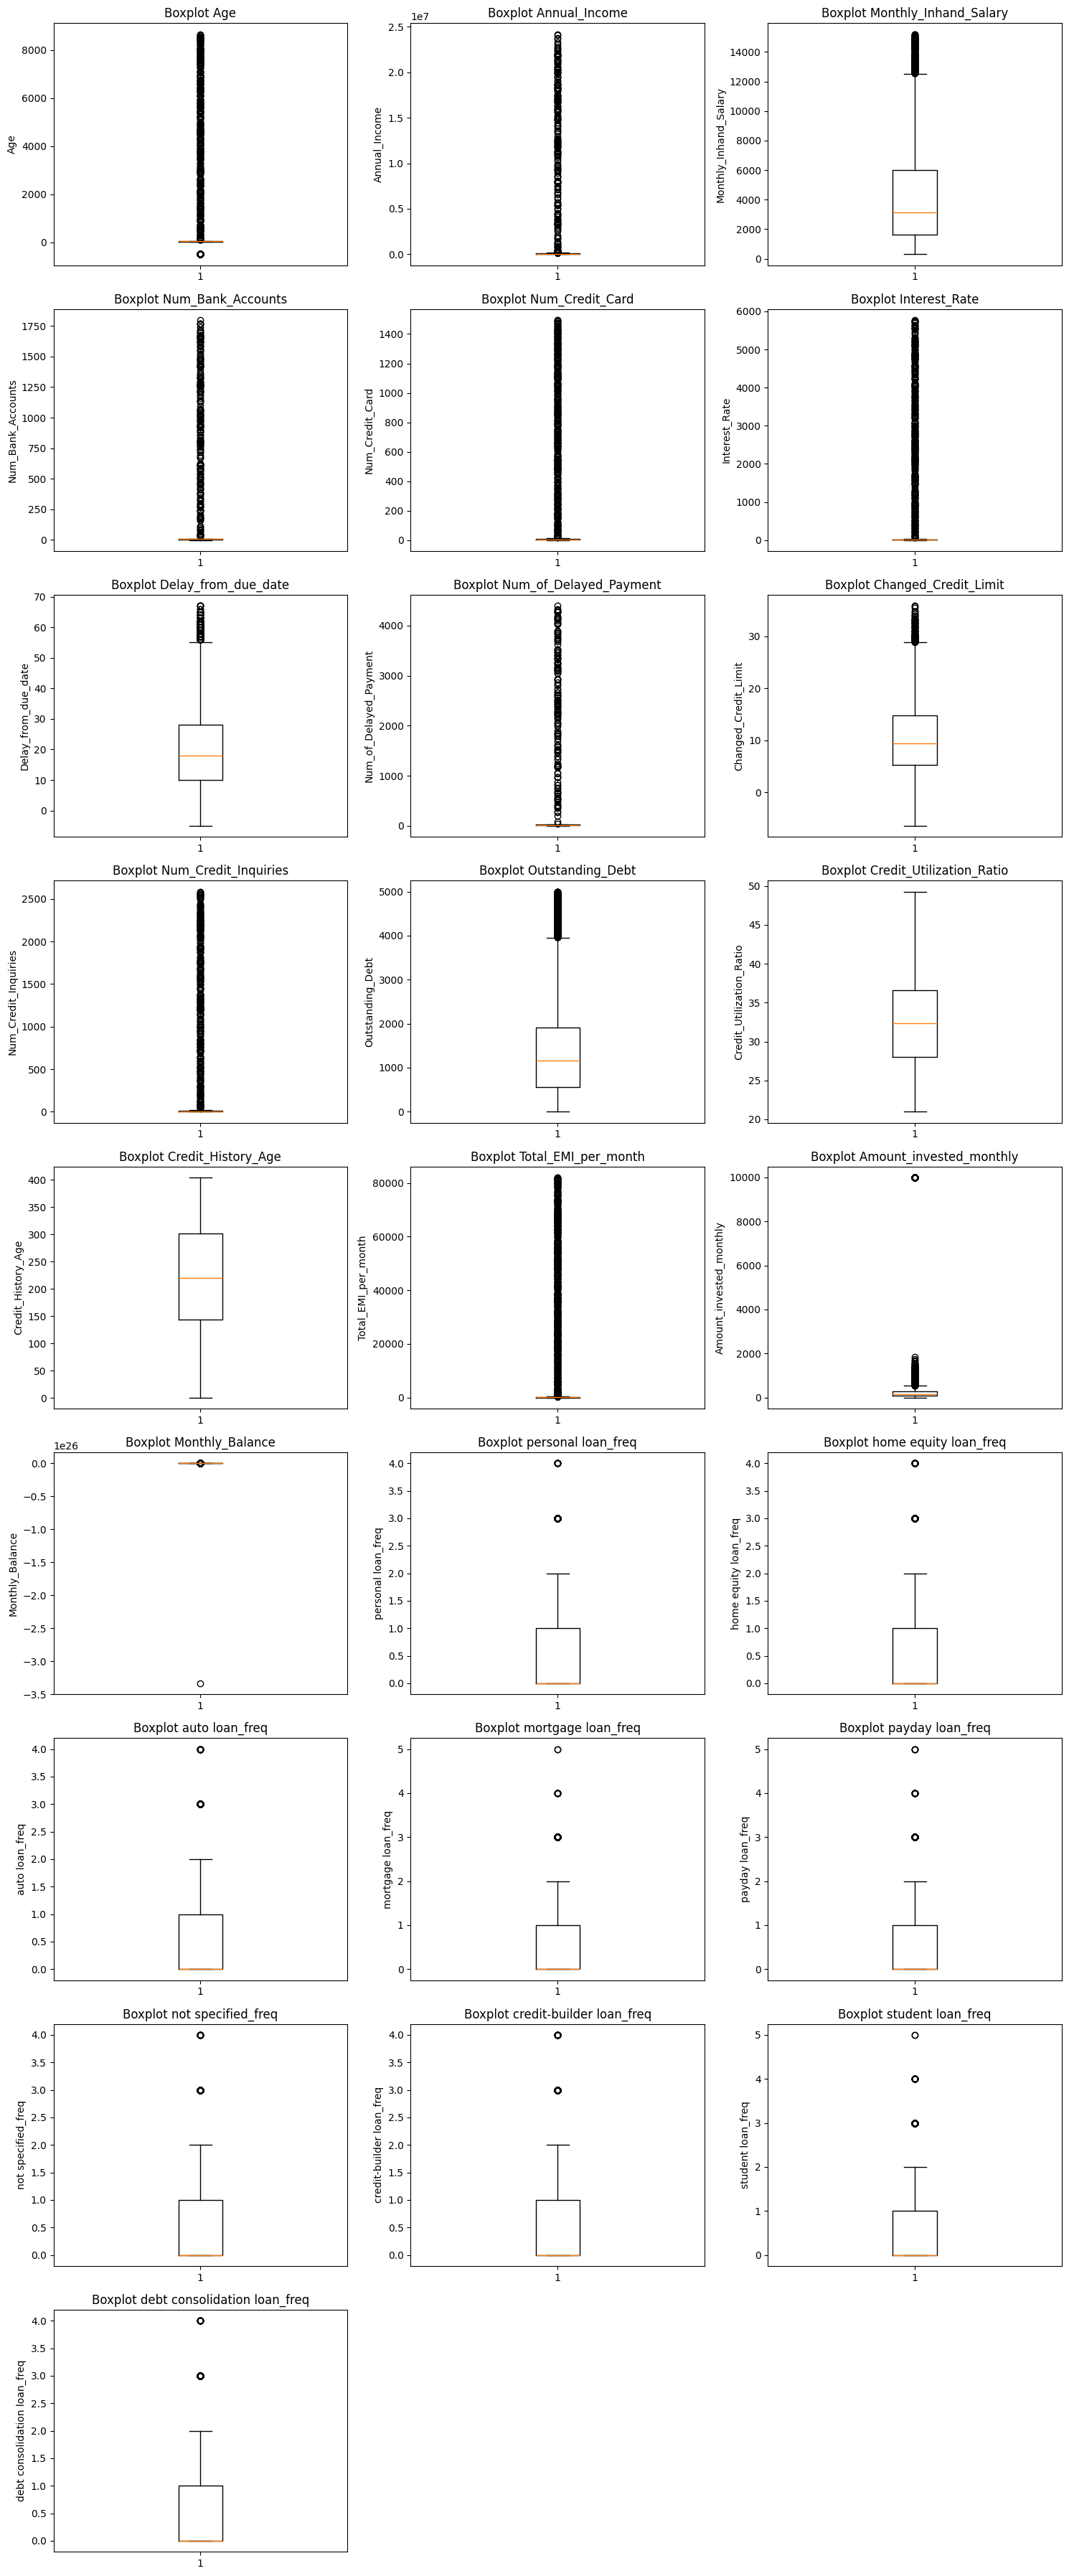

In [26]:
num_col = [c for c in x_train.columns if x_train[c].dtype != 'object']

n_cols = 3
n_rows = (len(num_col) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(num_col):
    axes[i].boxplot(x_train[col].dropna())
    axes[i].set_title(f'Boxplot {col}')
    axes[i].set_ylabel(col)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Range dari variable seperti Monthly_Inhand_Salary, Changed_Credit_Limit, dan Outstanding_Debt masih termasuk dalam range normal. Meskipun banyak outlier, values yang dimiliki masih masuk akal sehingga saya tidak akan menghandle outlier untuk 4 kolom tersebut. Begitu juga untuk Credit_History_Age dan Credit_Utilization_Ratio yang berada dalam range normal dan tidak ada outlier sehingga tidak akan ditangani.

Untuk Amount_invested_monthly sebenarnya mungkin saja mencapai 10000 USD, tapi sangat jarang. Namun mengingat adanya variasi data dalam dunia nyata, saya memutuskan untuk tidak handling outliernya

### a) Age
Untuk Age, saya mengambil range masuk akal di antara 0 sampai 110 tahun sehingga di luar range tersebut akan diubah menjadi missing value

In [27]:
x_train['Age'] = x_train['Age'].where(x_train['Age'].between(0, 110), np.nan)
x_test['Age'] = x_test['Age'].where(x_test['Age'].between(0, 110), np.nan)

### b) Monthly_Balance
Untuk Monthly_Balance, nilai maksimum masih masuk akal, namun tidak dengan nilai minimumnya yang negatif. Oleh karena itu, nilai dibawah 0 akan saya ubah menjadi missing value

In [28]:
x_train['Monthly_Balance'] = x_train['Monthly_Balance'].where(x_train['Monthly_Balance'] >= 0, np.nan)
x_test['Monthly_Balance'] = x_test['Monthly_Balance'].where(x_test['Monthly_Balance'] >= 0, np.nan)

### c) Kolom lainnya
Untuk kolom lainnya, yaitu Annual_Income, Num_Bank_Accounts, Num_Credit_Card, Interest_Rate, Num_of_Delayed_Payment, Num_Credit_Inquiries, dan Total_EMI_per_month, akan saya cek terlebih dahulu upper bound untuk extreme outlier, yaitu Q3+3IQR untuk melihat apakah value tersebut masih masuk akal untuk konteks kolom-kolom tersebut.

Untuk kolom-kolom yang masih memiliki value negatif, saya akan mengubah value dibawah 0 menjadi missing value

In [29]:
x_train.loc[:, x_train.columns].describe(exclude = ['object', 'int32'])

,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance
count,19424.000000,2.000000e+04,17006.000000,20000.000000,20000.000000,20000.000000,20000.000000,18596.000000,19576.000000,19608.000000,20000.000000,20000.000000,18168.000000,20000.000000,19138.000000,19777.000000
mean,33.415157,1.812475e+05,4212.754421,16.316350,22.199600,71.040250,20.967450,33.724134,10.350230,28.195940,1413.522515,32.307126,221.630559,1311.591110,663.479602,402.960452
std,10.776270,1.453274e+06,3176.343282,114.141549,128.798794,454.926868,14.778299,245.923985,6.774394,196.725856,1148.428935,5.142583,100.346697,7962.482745,2097.336284,213.893816
min,14.000000,7.006035e+03,303.645417,-1.000000,0.000000,1.000000,-5.000000,-3.000000,-6.450000,0.000000,0.230000,20.985606,1.000000,0.000000,0.000000,0.095482
25%,24.000000,1.955616e+04,1632.430000,3.000000,4.000000,8.000000,10.000000,9.000000,5.300000,3.000000,557.035000,28.000206,144.000000,30.306321,76.483074,269.668909
50%,33.000000,3.796316e+04,3130.127500,6.000000,5.000000,13.000000,18.000000,14.000000,9.370000,6.000000,1162.600000,32.337413,220.000000,69.612071,138.700024,337.069683
75%,42.000000,7.332700e+04,5989.025625,7.000000,7.000000,20.000000,28.000000,18.000000,14.760000,9.000000,1917.017500,36.571349,302.000000,160.540513,268.561251,472.458294
max,109.000000,2.417715e+07,15204.633333,1798.000000,1495.000000,5774.000000,67.000000,4397.000000,35.890000,2587.000000,4998.070000,49.254983,404.000000,82048.000000,10000.000000,1576.288935


In [30]:
def check_upperbound(col):
    Q1 = x_train[col].quantile(0.25)
    Q3 = x_train[col].quantile(0.75)    
    IQR = Q3 - Q1

    upper_bound = Q3 + 3 * IQR  
    print(f"Upper bound {col}: {upper_bound}")

rest_col = ['Annual_Income', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Delayed_Payment', 'Num_Credit_Inquiries', 'Total_EMI_per_month']
for col in rest_col:
    check_upperbound(col)

Upper bound Annual_Income: 234639.52
Upper bound Num_Bank_Accounts: 19.0
Upper bound Num_Credit_Card: 16.0
Upper bound Interest_Rate: 56.0
Upper bound Num_of_Delayed_Payment: 45.0
Upper bound Num_Credit_Inquiries: 27.0
Upper bound Total_EMI_per_month: 551.2430892467114


Untuk Total_EMI_per_month, upper bound masih terlalu kecil jika kita bandingkan dengan rangenya yang mencapai puluhan ribu dan sangat skew ke kanan, oleh karena itu saya kan mencoba cek percentilenya

In [31]:
print(x_train['Total_EMI_per_month'].quantile(0.99))

53506.449999999604


Meski valuenya masih cukup tinggi, namun akan saya beri kelonggaran mengingat adanya variasi dalam data credit score, sehingga saya hanya akan mengubah data yang valuenya di atas percentile 99 ini.

In [32]:
ub_cols = ['Annual_Income', 'Num_Bank_Accounts', 'Num_Credit_Card',
            'Interest_Rate', 'Num_of_Delayed_Payment', 'Num_Credit_Inquiries']

ub_bounds = {}
for c in ub_cols:
    q1, q3 = x_train[c].quantile([0.25, 0.75])
    iqr = q3 - q1
    ub_bounds[c] = (0, q3 + 3 * iqr)        

emi = x_train['Total_EMI_per_month'].quantile(0.99)  

def apply_bounds(df):
    df = df.copy()
    for c, (lo, hi) in ub_bounds.items():
        df[c] = df[c].where(df[c].between(lo, hi), np.nan)
    
    df['Total_EMI_per_month'] = df['Total_EMI_per_month'].where(
        df['Total_EMI_per_month'] <= emi, np.nan)
    return df

x_train = apply_bounds(x_train)
x_test  = apply_bounds(x_test)      

In [33]:
x_train.loc[:, x_train.columns].describe(exclude = ['object', 'int32'])

,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance
count,19424.000000,19789.000000,17006.000000,19758.000000,19558.000000,19585.000000,20000.000000,18305.000000,19576.000000,19269.000000,20000.000000,20000.000000,18168.000000,19800.000000,19138.000000,19777.000000
mean,33.415157,50741.033225,4212.754421,5.366535,5.520759,14.511412,20.967450,13.407594,10.350230,5.768125,1413.522515,32.307126,221.630559,644.628192,663.479602,402.960452
std,10.776270,38169.961526,3176.343282,2.601734,2.074704,8.656125,14.778299,6.214594,6.774394,3.873680,1148.428935,5.142583,100.346697,4340.165042,2097.336284,213.893816
min,14.000000,7006.035000,303.645417,0.000000,0.000000,1.000000,-5.000000,0.000000,-6.450000,0.000000,0.230000,20.985606,1.000000,0.000000,0.000000,0.095482
25%,24.000000,19455.490000,1632.430000,3.000000,4.000000,8.000000,10.000000,9.000000,5.300000,3.000000,557.035000,28.000206,144.000000,30.061075,76.483074,269.668909
50%,33.000000,37404.670000,3130.127500,5.000000,5.000000,13.000000,18.000000,14.000000,9.370000,5.000000,1162.600000,32.337413,220.000000,68.552437,138.700024,337.069683
75%,42.000000,71933.700000,5989.025625,7.000000,7.000000,20.000000,28.000000,18.000000,14.760000,8.000000,1917.017500,36.571349,302.000000,155.753145,268.561251,472.458294
max,109.000000,179987.280000,15204.633333,11.000000,11.000000,34.000000,67.000000,28.000000,35.890000,17.000000,4998.070000,49.254983,404.000000,53504.000000,10000.000000,1576.288935


In [34]:
x_test.loc[:, x_test.columns].describe(exclude = ['object', 'int32'])

,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance
count,4859.000000,4943.000000,4238.000000,4944.000000,4886.000000,4891.000000,5000.00000,4608.000000,4892.000000,4822.000000,5000.000000,5000.000000,4540.000000,4953.000000,4802.000000,4920.000000
mean,33.305618,49890.591039,4163.457546,5.395429,5.568359,14.511756,21.27700,13.501302,10.420699,5.778930,1437.759830,32.243302,221.714758,611.801244,639.286950,397.667410
std,10.822411,37330.622243,3132.142446,2.565664,2.050572,8.756745,14.96458,6.261399,6.776553,3.871144,1131.981702,5.110084,99.990594,4142.696195,2046.084308,208.305085
min,14.000000,7006.035000,319.556250,0.000000,1.000000,1.000000,-5.00000,0.000000,-6.490000,0.000000,0.770000,20.257073,5.000000,0.000000,0.000000,0.007760
25%,24.000000,19387.720000,1638.422188,3.000000,4.000000,7.000000,10.00000,9.000000,5.390000,3.000000,590.290000,28.022938,142.000000,31.606535,73.914335,268.372186
50%,33.000000,36863.790000,3080.454167,6.000000,5.000000,13.000000,18.00000,14.000000,9.365000,5.000000,1196.875000,32.085850,221.000000,68.248891,137.930059,334.389527
75%,42.000000,71020.235000,5927.527500,7.000000,7.000000,20.000000,28.00000,18.000000,15.020000,8.000000,1964.145000,36.443942,304.000000,158.375856,269.140925,469.298537
max,56.000000,179078.280000,15167.180000,11.000000,11.000000,34.000000,67.00000,28.000000,36.490000,26.000000,4982.570000,46.979229,401.000000,52624.000000,10000.000000,1567.208309


## Check Missing Value

In [35]:
x_train.isnull().sum()

Month                              0
Age                              576
Occupation                      1409
Annual_Income                    211
Monthly_Inhand_Salary           2994
Num_Bank_Accounts                242
Num_Credit_Card                  442
Interest_Rate                    415
Delay_from_due_date                0
Num_of_Delayed_Payment          1695
Changed_Credit_Limit             424
Num_Credit_Inquiries             731
Credit_Mix                      4154
Outstanding_Debt                   0
Credit_Utilization_Ratio           0
Credit_History_Age              1832
Payment_of_Min_Amount              0
Total_EMI_per_month              200
Amount_invested_monthly          862
Monthly_Balance                  223
personal loan_freq                 0
home equity loan_freq              0
auto loan_freq                     0
mortgage loan_freq                 0
payday loan_freq                   0
not specified_freq                 0
credit-builder loan_freq           0
s

In [36]:
x_test.isnull().sum()

Month                              0
Age                              141
Occupation                       383
Annual_Income                     57
Monthly_Inhand_Salary            762
Num_Bank_Accounts                 56
Num_Credit_Card                  114
Interest_Rate                    109
Delay_from_due_date                0
Num_of_Delayed_Payment           392
Changed_Credit_Limit             108
Num_Credit_Inquiries             178
Credit_Mix                      1018
Outstanding_Debt                   0
Credit_Utilization_Ratio           0
Credit_History_Age               460
Payment_of_Min_Amount              0
Total_EMI_per_month               47
Amount_invested_monthly          198
Monthly_Balance                   80
personal loan_freq                 0
home equity loan_freq              0
auto loan_freq                     0
mortgage loan_freq                 0
payday loan_freq                   0
not specified_freq                 0
credit-builder loan_freq           0
s

## Drop Kolom Month
Karena disini kita ingin prediksi Credit_Score, kolom Month menjadi kurang relevan karena ini hanya menunjukan timestamp dari dataset yang dimiliki dimana kita memiliki data bulanan untuk setiap customer. Jika kolom ini tetap dipakai, bisa aja model bias karena menganggap month sebagai fitur. Misal kebanyakan data customer di bulan Maret Credit_Scorenya Poor, model akan condong memprediksi customer dengan Month Maret sebagai Poor. Meski mungkin pengaruhnya kecil, namun lebih baik didrop saja kolom ini.

In [37]:
x_train = x_train.drop(columns='Month')
x_test = x_test.drop(columns='Month')

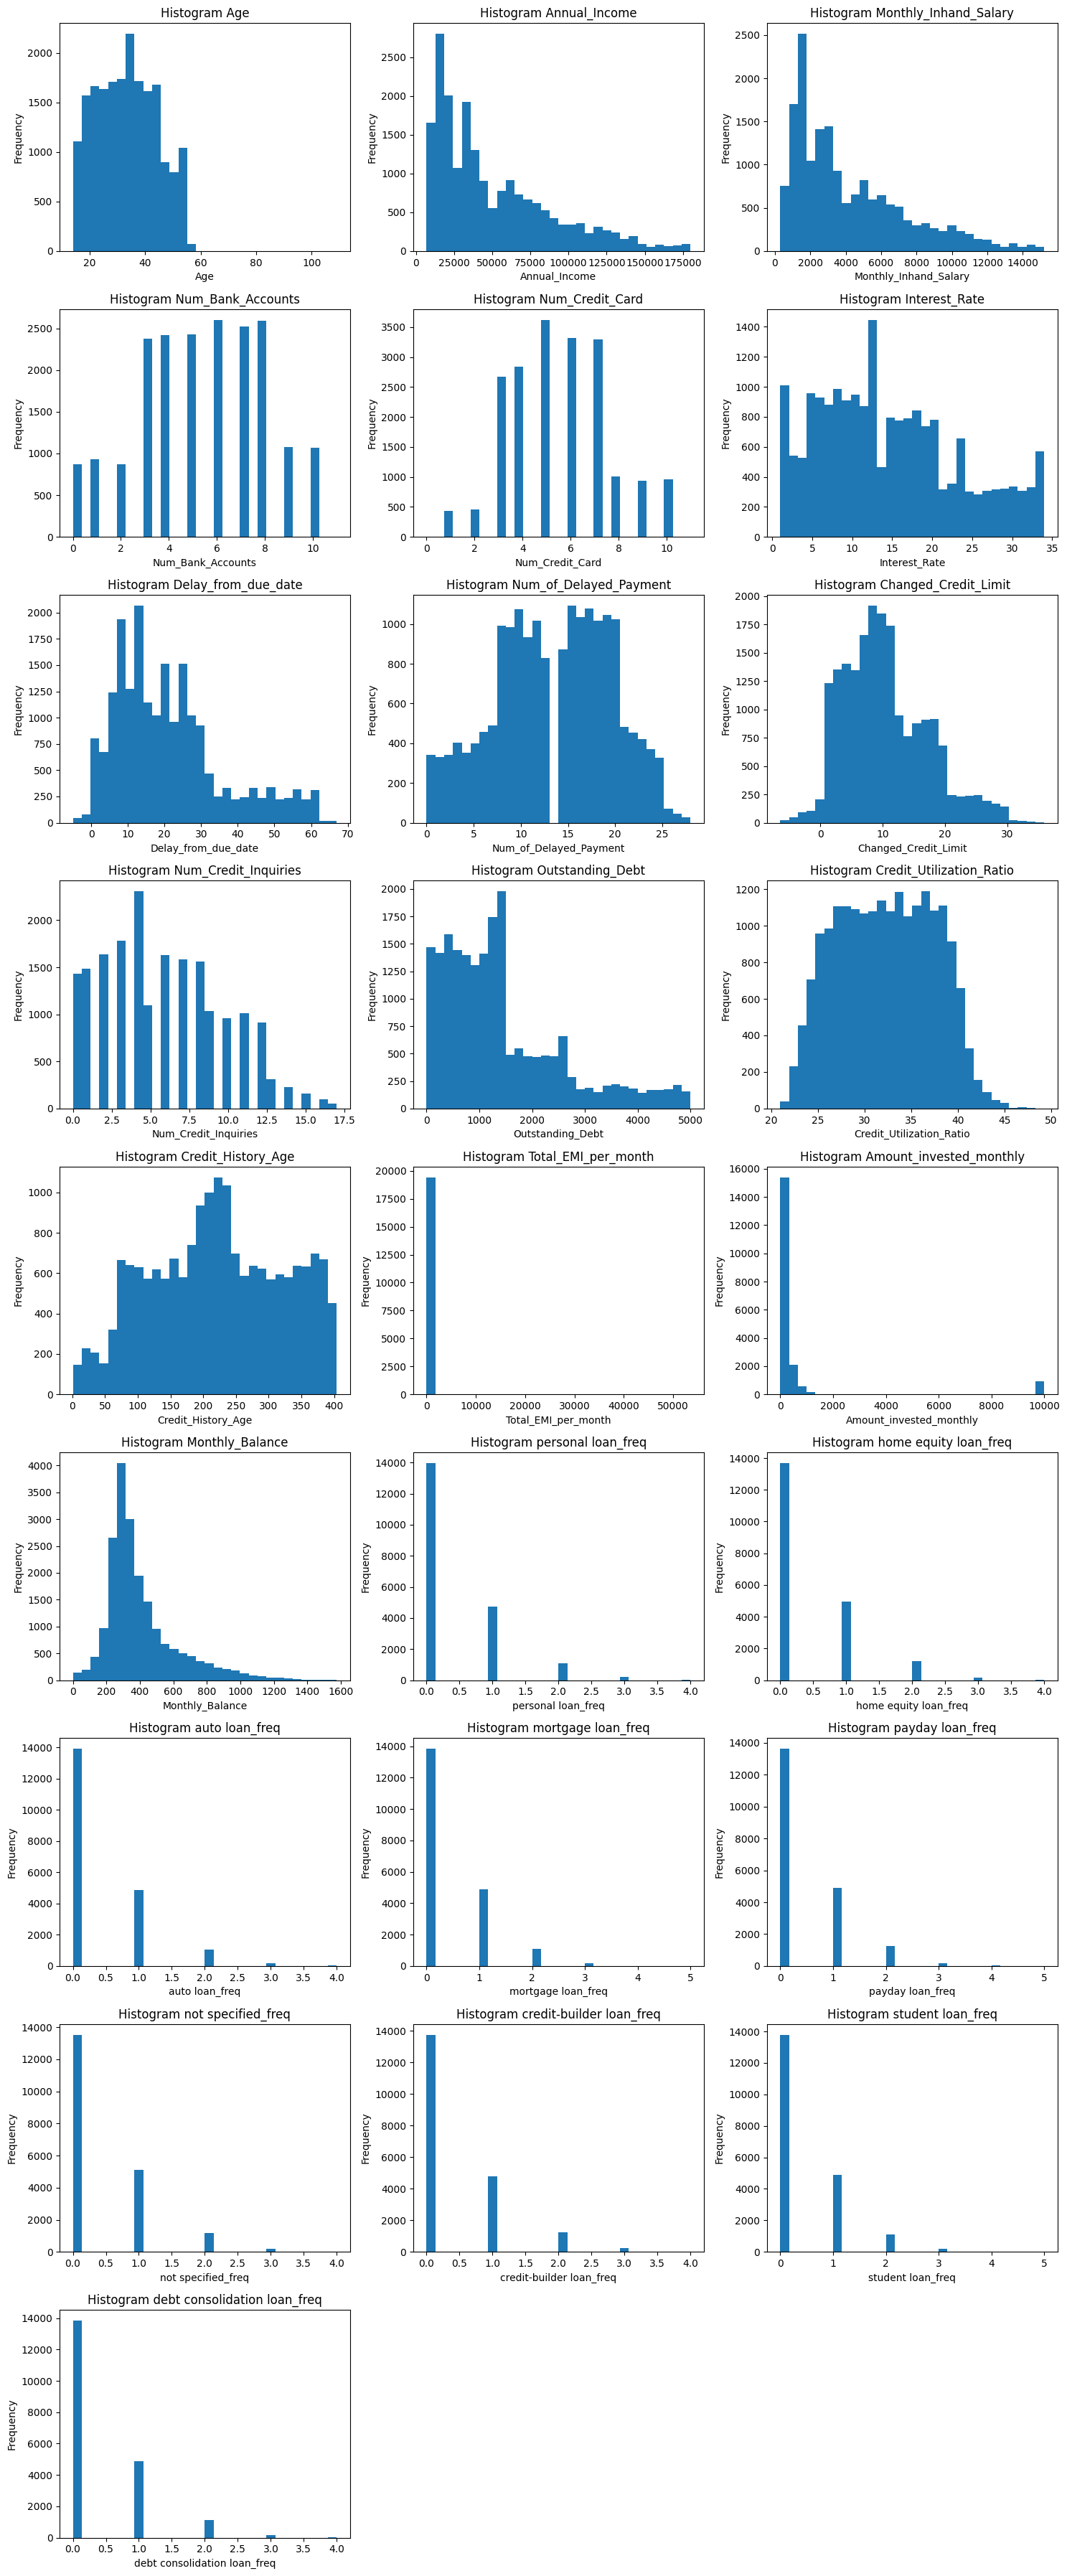

In [38]:
num_col = [c for c in x_train.columns if x_train[c].dtype != 'object']

n_cols = 3
n_rows = (len(num_col) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(num_col):
    axes[i].hist(x_train[col].dropna(), bins=30)
    axes[i].set_title(f'Histogram {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Setelah menangani outlier, disini kita bisa melihat distribusi dari kolom numerikal dimana sebagian besar skewed. Oleh karena itu, akan saya imputasi menggunakan median seluruhnya.

# Handling Missing Value & Feature Engineering

Untuk kolom penghasilan seperti Annual_Income dan Monthly_Inhand_Salary, akan dilakukan imputasi menggunakan median berdasarkan Occupation. Cara ini dipilih agar nilai imputasi lebih representatif dan tidak menimbulkan bias yang dapat terjadi jika menggunakan median dari kolom tersebut saja. Individu dengan jenis pekerjaan yang sama cenderung memiliki rentang penghasilan yang relatif serupa, sehingga median per kelompok pekerjaan dapat mencerminkan karakteristik pendapatan yang lebih realistis. Dengan demikian, nilai yang dihasilkan setelah imputasi tetap mempertahankan pola hubungan antara pekerjaan dan tingkat penghasilan dalam data, serta mengurangi distorsi yang dapat memengaruhi proses analisis maupun pemodelan.

In [39]:
group_cols = ['Annual_Income','Monthly_Inhand_Salary']
occ_median = {c: x_train.groupby('Occupation')[c].median() for c in group_cols}
global_med = {c: x_train[c].median() for c in group_cols}

def group_impute(df):
    df = df.copy()
    for c in group_cols:
        fill = df['Occupation'].map(occ_median[c]).fillna(global_med[c])
        df[c] = df[c].fillna(fill)
    return df

x_train = group_impute(x_train)
x_test  = group_impute(x_test)

In [40]:
cat_cols = [c for c in x_train.columns if x_train[c].dtype == 'object']
for c in cat_cols:
    print(f"Total unique values in {c}: {x_train[c].nunique()}")
    print(x_train[c].value_counts(), "\n")

Total unique values in Occupation: 15
Occupation
Accountant       1319
Lawyer           1307
Architect        1291
Engineer         1269
Scientist        1263
Media_Manager    1251
Writer           1242
Entrepreneur     1242
Doctor           1235
Mechanic         1230
Journalist       1201
Developer        1198
Manager          1192
Teacher          1188
Musician         1163
Name: count, dtype: int64 

Total unique values in Credit_Mix: 3
Credit_Mix
Standard    7268
Good        4854
Bad         3724
Name: count, dtype: int64 

Total unique values in Payment_of_Min_Amount: 3
Payment_of_Min_Amount
Yes    10380
No      7121
NM      2499
Name: count, dtype: int64 

Total unique values in Spent_Level: 2
Spent_Level
Low     9969
High    8516
Name: count, dtype: int64 

Total unique values in Payment_Value: 3
Payment_Value
Small     7390
Medium    6324
Large     4771
Name: count, dtype: int64 



Missing value pada kolom numerical selain Annual_Income dan Monthly_Inhand_Salary akan diimputasi menggunakan median dari data train. Median dipilih karena sebagian besar fitur numerik memiliki distribusi yang skewed sehingga lebih robust dibandingkan rata-rata (mean) terhadap keberadaan outlier. Selain itu, perhitungan hanya menggunakan data train dilakukan untuk menghindari terjadinya data leakage. 

Kolom numerik juga akan discaling melihat adanya perbedaan skala antar fitur, seperti Num_Credit_Card yang hanya puluhan sedangkan Annual_Income mencapai ratusan ribu. Scaling menjadi penting karena saya juga melakukan eksperimen training ke model yang sensitif terhadap perbedaan skala dan outlier seperti Logistic Regression dan SVC. Saya akan melakukan scaling menggunakan Robust Scaler. Metode ini dipilih karena banyak fitur memiliki distribusi yang tidak simetris dan masih mengandung outlier. Berbeda dengan Standard Scaler yang menggunakan rata-rata dan standar deviasi, Robust Scaler menggunakan median dan Interquartile Range (IQR) sehingga lebih tahan terhadap pengaruh nilai ekstrim.

Untuk nominal variable seperti Occupation dan Payment_of_Min_Amount akan diencoding menggunakan One Hot Encoder. Sedangkan variable seperti Credit_Mix, Spent_Level, dan Payment_Value, mereka memiliki urutan/ranking. Contohnya Payment_Value yang memiliki urutan Small, Medium, Large. Oleh karena itu, variable-variable tersebut akan diencoding menggunakan Ordinal Encoder.

Untuk missing value pada categorical column akan diimputasi menggunakan modus berdasarkan data train agar tidak terjadi data leak.

In [41]:
num_cols = x_train.select_dtypes(include='number').columns.tolist()   

numeric_preprocess = Pipeline([
    ('num_imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

ohe_col = ['Occupation', 'Payment_of_Min_Amount']
ohe_preprocess = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('cat_onehot_encoder', OneHotEncoder(handle_unknown='ignore'))
])

ordinal_col = ['Credit_Mix', 'Spent_Level', 'Payment_Value']
ordinal_categories = [
    ['Bad', 'Standard', 'Good'],      
    ['Low', 'High'],                  
    ['Small', 'Medium', 'Large'],     
]

ordinal_preprocess = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('cat_ordinal_encoder', OrdinalEncoder(categories=ordinal_categories,
                                           handle_unknown='use_encoded_value', unknown_value=-1))
])

preprocess = ColumnTransformer([
    ('num', numeric_preprocess, num_cols),
    ('ohe', ohe_preprocess, ohe_col),
    ('ordinal', ordinal_preprocess, ordinal_col)
], remainder='drop')

# Modeling
Untuk menangani data imbalance, kita bisa menggunakan class weight balanced dan SMOTE atau oversampling. Saya akan mencoba keduanya

## a) Logistic Regression

In [42]:
lr_pred = Pipeline([
    ('preprocessing', preprocess),
    ('classifier', LogisticRegression(random_state=42, class_weight='balanced'))
])

lr_pred_smote = ImbPipeline([
    ('preprocessing', preprocess),
    ('smote', SMOTE(random_state=42)),
    ('classifier', LogisticRegression(random_state=42))
])

## b) Random Forest

In [43]:
rf_pred = Pipeline([
    ('preprocessing', preprocess),
    ('classifier', RandomForestClassifier(random_state=42, class_weight='balanced'))
])

rf_pred_smote = ImbPipeline([
    ('preprocessing', preprocess),
    ('smote', SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(random_state=42))
])

## c) XGBoost

XGBoost memiliki konsep balancing class yang berbeda yaitu menggunakan compute_sample_weight dan sample_weight. Di notebook ini akan digunakan sekaligus saat training nanti.

In [44]:
xgb_pred = Pipeline([
    ('preprocessing', preprocess),
    ('classifier', XGBClassifier(random_state=42))
])

xgb_pred_smote = ImbPipeline([
    ('preprocessing', preprocess),
    ('smote', SMOTE(random_state=42)),
    ('classifier', XGBClassifier(random_state=42))
])

## d) LightGBM

In [45]:
lgb_pred = Pipeline([
    ('preprocessing', preprocess),
    ('classifier', LGBMClassifier(
        random_state=42, class_weight='balanced'))
])

lgb_pred_smote = ImbPipeline([
    ('preprocessing', preprocess),
    ('smote', SMOTE(random_state=42)),
    ('classifier', LGBMClassifier(random_state=42))
])

## e) CatBoost

In [46]:
cat_pred = Pipeline([
    ('preprocessing', preprocess),
    ('classifier', CatBoostClassifier(
        random_state=42, auto_class_weights='Balanced'))
])

cat_pred_smote = ImbPipeline([
    ('preprocessing', preprocess),
    ('smote', SMOTE(random_state=42)),
    ('classifier', CatBoostClassifier(random_state=42))
])

## f) SVC

In [47]:
svc_pred = Pipeline([
    ('preprocessing', preprocess),
    ('classifier', SVC(random_state=42, class_weight='balanced'))
])

svc_pred_smote = ImbPipeline([
    ('preprocessing', preprocess),
    ('smote', SMOTE(random_state=42)),
    ('classifier', SVC(random_state=42))
])

Saya menggunakan teknik cross-validation pada proses pelatihan model untuk memastikan bahwa performa model yang diperoleh tidak hanya kebetulan baik pada satu pembagian data tertentu, melainkan konsisten dan dapat digeneralisasi dengan baik ke data lain.

In [48]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
sample_weight = compute_sample_weight('balanced', y_train)

scoring = {
    'f1_macro':       make_scorer(f1_score, average='macro'),
    'recall_poor':    make_scorer(recall_score, labels=[0], average='macro', zero_division=0),  
    'precision_good': make_scorer(precision_score, labels=[2], average='macro', zero_division=0),  
}

def run_cv(models, use_sample_weight=True):
    results = {}
    for model_name, model in models.items():
        fit_params = ({'classifier__sample_weight': sample_weight}
                      if (use_sample_weight and 'XGB' in model_name) else {})
        
        scores = cross_validate(model, x_train, y_train, cv=cv, scoring=scoring,
                                n_jobs=-1, error_score='raise', fit_params=fit_params)
        
        results[model_name] = {
            'F1 Macro':       round(scores['test_f1_macro'].mean(), 4),
            'Recall Poor':    round(scores['test_recall_poor'].mean(), 4),
            'Precision Good': round(scores['test_precision_good'].mean(), 4),
        }
    return (pd.DataFrame(results).T
            .sort_values('F1 Macro', ascending=False))   

### Using Class Weight Balanced

In [49]:
models_balanced = {
    'Logistic Regression': lr_pred,
    'Random Forest': rf_pred,
    'XGBoost': xgb_pred,
    'LightGBM': lgb_pred,
    'CatBoost': cat_pred,
    'SVC': svc_pred
}
print(f"Cross-Validation Results — Class Weight Balanced Models")
run_cv(models_balanced)

Cross-Validation Results — Class Weight Balanced Models


,F1 Macro,Recall Poor,Precision Good
Random Forest,0.7072,0.6943,0.6609
XGBoost,0.6996,0.7415,0.5681
CatBoost,0.6981,0.7511,0.5548
LightGBM,0.6893,0.7516,0.5373
SVC,0.6220,0.6903,0.4395
Logistic Regression,0.6161,0.6760,0.4492


### Using SMOTE

In [50]:
models_smote = {
    'Logistic Regression': lr_pred_smote,
    'Random Forest': rf_pred_smote,
    'XGBoost': xgb_pred_smote,
    'LightGBM': lgb_pred_smote,
    'CatBoost': cat_pred_smote,
    'SVC': svc_pred_smote
}
print(f"Cross-Validation Results — SMOTE Models")
run_cv(models_smote, use_sample_weight=False)

Cross-Validation Results — SMOTE Models


,F1 Macro,Recall Poor,Precision Good
Random Forest,0.7151,0.7426,0.6025
CatBoost,0.7006,0.6997,0.6153
XGBoost,0.6947,0.6806,0.6250
LightGBM,0.6922,0.6833,0.5956
SVC,0.6352,0.6925,0.4632
Logistic Regression,0.6208,0.6708,0.4631


Saya menggunakan metric **F1 Macro**, **Recall kelas 0 (Poor)** dan **Precision kelas 2 (Good)**.

**F1 Macro Average**  
Metrik ini dipilih sebagai metrik utama karena target klasifikasi (Credit_Score) bersifat imbalanced. Dalam kondisi ini, metric seperti accuracy dapat menyesatkan karena bisa tinggi hanya dengan memprediksi kelas mayoritas. F1 macro menghitung rata-rata F1-score dari semua kelas secara setara (tidak ter-bias pada kelas mayoritas), sehingga memberikan gambaran yang lebih adil tentang performa model di semua kelas.

**Recall kelas 0 (Poor)**  
Recall menunjukkan dari seluruh nasabah yang benar-benar berada pada kategori Poor, berapa banyak yang berhasil terdeteksi oleh model. Metrik ini penting karena kesalahan yang paling ingin dihindari adalah ketika nasabah yang sebenarnya berisiko tinggi justru diprediksi sebagai Standard atau Good (false negative). Jika hal tersebut terjadi, nasabah yang seharusnya mendapat perhatian lebih dapat dianggap layak menerima kredit, sehingga berpotensi meningkatkan risiko gagal bayar. Oleh karena itu, semakin tinggi recall pada kelas Poor, semakin banyak nasabah berisiko yang berhasil teridentifikasi.

**Precision kelas 2 (Good)**  
Precision menunjukkan dari seluruh nasabah yang diprediksi sebagai Good, berapa banyak yang memang benar-benar termasuk kategori Good. Metrik ini penting untuk mengurangi false positive, yaitu kondisi ketika nasabah diprediksi Good padahal sebenarnya memiliki tingkat risiko yang lebih tinggi. Dengan precision yang tinggi pada kelas Good, model menjadi lebih selektif dalam memberikan prediksi tersebut. Hal ini membantu mengurangi risiko pemberian kredit atau fasilitas yang lebih menguntungkan kepada nasabah yang sebenarnya belum layak menerimanya.

---
Ketika kita bandingkan ketiga metric tersebut pada tabel hasil cross validation, baik yang menggunakan class weight balanced maupun SMOTE, terlihat bahwa 3 model terbaik yaitu Random Forest yang konsisten mendominasi di kedua tabel, diikuti CatBoost dan XGBoost yang saling bergantian posisi.

Random Forest menghasilkan metrik evaluasi tertinggi dibandingkan lima model lainnya. Dengan class weight balanced, model ini mencapai F1-Macro 0.7072, yang menunjukkan keseimbangan terbaik antara precision dan recall pada seluruh kelas. Recall Poor sebesar 0.6943 menunjukkan bahwa sekitar 69.43% nasabah yang benar-benar berada pada kategori Poor berhasil terdeteksi oleh model. Sementara itu, Precision Good sebesar 0.6609 menunjukkan bahwa sekitar 66.09% nasabah yang diprediksi Good memang benar-benar termasuk kategori tersebut. Ketika menggunakan SMOTE, performa Random Forest meningkat pada hampir seluruh metrik. Nilai F1-Macro naik menjadi 0.7151 dan Recall Poor meningkat menjadi 0.7426, meskipun Precision Good sedikit menurun menjadi 0.6025. Secara keseluruhan, Random Forest dengan SMOTE memberikan performa terbaik di antara seluruh model yang diuji.

XGBoost menempati posisi kedua pada tabel class weight balanced dengan F1-Macro 0.6996 dan Recall Poor yang cukup tinggi di 0.7415, namun Precision Goodnya hanya 0.5681, yang berarti hampir setengah dari prediksi Good ternyata salah. Pada tabel SMOTE, XGBoost turun ke posisi ketiga dengan F1-Macro 0.6947, tetapi menariknya justru Precision Goodnya membaik signifikan menjadi 0.6250, yang menandakan SMOTE membantu model ini lebih selektif dalam mengklasifikasikan nasabah sebagai Good.

CatBoost menunjukkan pola yang mirip dengan XGBoost. Pada pendekatan class weight balanced, CatBoost memperoleh F1-Macro 0.6981 dengan Recall Poor 0.7511, yang merupakan salah satu nilai recall tertinggi. Namun, Precision Good masih relatif rendah yaitu 0.5548. Setelah menggunakan SMOTE, F1-Macro meningkat menjadi 0.7006 dan Precision Good naik menjadi 0.6153, meskipun Recall Poor sedikit turun menjadi 0.6997. Hasil ini menunjukkan bahwa SMOTE membantu CatBoost mencapai keseimbangan yang lebih baik antara kemampuan mendeteksi nasabah berisiko dan ketepatan dalam mengidentifikasi nasabah berkualitas baik.

Meskipun penggunaan SMOTE menghasilkan metrik evaluasi yang sedikit lebih baik, model akhir tetap dipilih menggunakan pendekatan class weight balanced. Pertimbangan utamanya adalah konsistensi antara kondisi pelatihan dan kondisi saat deployment. Pada lingkungan produksi, data baru yang masuk untuk inferensi tidak akan melalui proses oversampling seperti SMOTE, melainkan tetap mengikuti distribusi aslinya yang tidak seimbang. Dengan class weight balanced, model dilatih untuk memberikan perhatian lebih pada kelas minoritas tanpa mengubah distribusi data. Pendekatan ini membuat kondisi pelatihan lebih mendekati kondisi nyata yang akan dihadapi model saat digunakan. Selain itu, model juga jadi tidak bergantung pada sampel sintetis yang hanya muncul selama proses pelatihan, sehingga diharapkan memiliki kemampuan generalisasi yang lebih baik terhadap data nyata.

# Hyperparameter Tuning 3 Model Terbaik dengan Class Weight Balanced
Saya akan melakukan tuning untuk 3 model terbaik dengan class weight balanced, yaitu Random Forest, XGBoost, dan CatBoost untuk mencari konfigurasi parameter terbaik supaya performa model menjadi optimal.

In [51]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def tune(pipe, param_dist, n_iter=20, sample_weight=None):
    search = RandomizedSearchCV(pipe, param_dist, n_iter=n_iter, scoring='f1_macro',
                                cv=cv, n_jobs=-1, random_state=42, verbose=1)
    if sample_weight is not None:
        search.fit(x_train, y_train, classifier__sample_weight=sample_weight)
    else:
        search.fit(x_train, y_train)
    print(f"Best params: {search.best_params_}")
    print(f"Best CV F1 Macro: {search.best_score_:.4f}")
    return search.best_estimator_

In [52]:
rf_params = {
    'classifier__n_estimators':     [50, 100, 150],
    'classifier__max_depth':        [10, 20, 30, None],
    'classifier__min_samples_split':[2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4],
    'classifier__max_features':     ['sqrt', 'log2'],
}

rf_best  = tune(rf_pred,  rf_params)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best params: {'classifier__n_estimators': 150, 'classifier__min_samples_split': 5, 'classifier__min_samples_leaf': 2, 'classifier__max_features': 'sqrt', 'classifier__max_depth': None}
Best CV F1 Macro: 0.7147



Classification report:
              precision    recall  f1-score   support

           0       0.76      0.75      0.75      1440
           1       0.80      0.74      0.77      2651
           2       0.61      0.75      0.67       909

    accuracy                           0.74      5000
   macro avg       0.72      0.75      0.73      5000
weighted avg       0.75      0.74      0.75      5000



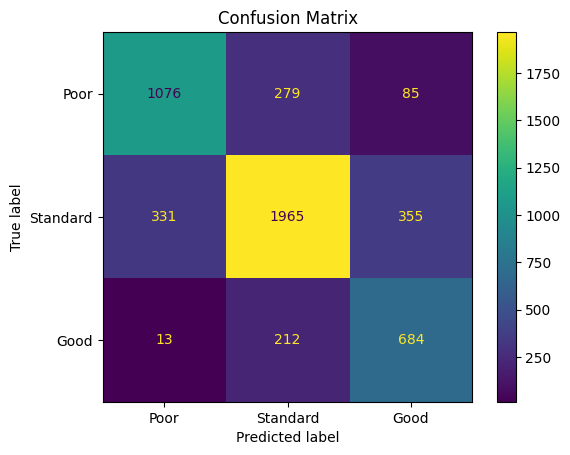

In [53]:
rf_y_pred = rf_best.predict(x_test)

print("\nClassification report:")
print(classification_report(y_test, rf_y_pred))

cm = confusion_matrix(y_test, rf_y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Poor','Standard','Good'])

disp.plot()
plt.title("Confusion Matrix")
plt.show()

In [54]:
xgb_params = {
    'classifier__n_estimators':   [50, 100, 150],
    'classifier__max_depth':      [3, 5, 7],
    'classifier__learning_rate':  [0.01, 0.05, 0.1],
    'classifier__subsample':      [0.7, 0.8, 1.0],
    'classifier__colsample_bytree':[0.7, 0.8, 1.0],
}

xgb_best = tune(xgb_pred, xgb_params, sample_weight=sample_weight)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best params: {'classifier__subsample': 1.0, 'classifier__n_estimators': 150, 'classifier__max_depth': 7, 'classifier__learning_rate': 0.1, 'classifier__colsample_bytree': 0.8}
Best CV F1 Macro: 0.7003



Classification report:
              precision    recall  f1-score   support

           0       0.70      0.77      0.74      1440
           1       0.83      0.66      0.74      2651
           2       0.57      0.81      0.67       909

    accuracy                           0.72      5000
   macro avg       0.70      0.75      0.71      5000
weighted avg       0.75      0.72      0.72      5000



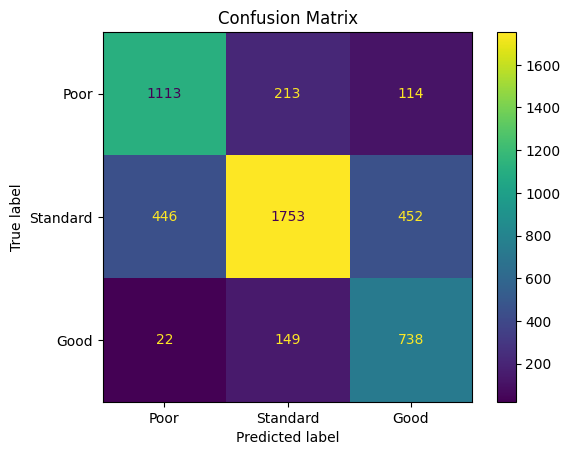

In [55]:
xgb_y_pred = xgb_best.predict(x_test)

print("\nClassification report:")
print(classification_report(y_test, xgb_y_pred))

cm = confusion_matrix(y_test, xgb_y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Poor','Standard','Good'])

disp.plot()
plt.title("Confusion Matrix")
plt.show()

In [56]:
cat_params = {
    'classifier__iterations':    [50, 80, 100],
    'classifier__depth':         [4, 6, 8],
    'classifier__learning_rate': [0.01, 0.05, 0.1],
    'classifier__l2_leaf_reg':   [1, 3, 5],
}

cat_best = tune(cat_pred, cat_params)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
0:	learn: 1.0424397	total: 235ms	remaining: 18.6s
1:	learn: 0.9938426	total: 307ms	remaining: 12s
2:	learn: 0.9572359	total: 392ms	remaining: 10.1s
3:	learn: 0.9269203	total: 477ms	remaining: 9.05s
4:	learn: 0.9006317	total: 538ms	remaining: 8.07s
5:	learn: 0.8740551	total: 607ms	remaining: 7.48s
6:	learn: 0.8536975	total: 679ms	remaining: 7.08s
7:	learn: 0.8360655	total: 768ms	remaining: 6.91s
8:	learn: 0.8203215	total: 847ms	remaining: 6.68s
9:	learn: 0.8078238	total: 959ms	remaining: 6.71s
10:	learn: 0.7962890	total: 1.04s	remaining: 6.52s
11:	learn: 0.7873604	total: 1.11s	remaining: 6.28s
12:	learn: 0.7756708	total: 1.18s	remaining: 6.09s
13:	learn: 0.7668756	total: 1.26s	remaining: 5.92s
14:	learn: 0.7589122	total: 1.33s	remaining: 5.77s
15:	learn: 0.7515935	total: 1.39s	remaining: 5.58s
16:	learn: 0.7462083	total: 1.47s	remaining: 5.45s
17:	learn: 0.7404814	total: 1.55s	remaining: 5.33s
18:	learn: 0.7347596	total: 1.62


Classification report:
              precision    recall  f1-score   support

           0       0.65      0.78      0.71      1440
           1       0.84      0.58      0.69      2651
           2       0.53      0.82      0.64       909

    accuracy                           0.68      5000
   macro avg       0.67      0.73      0.68      5000
weighted avg       0.73      0.68      0.69      5000



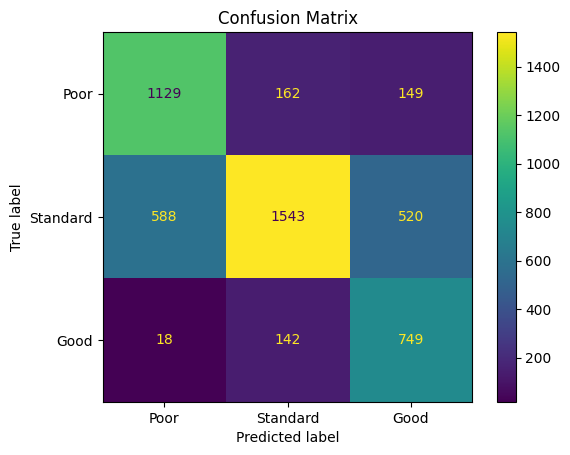

In [57]:
cat_y_pred = cat_best.predict(x_test)

print("\nClassification report:")
print(classification_report(y_test, cat_y_pred))

cm = confusion_matrix(y_test, cat_y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Poor','Standard','Good'])

disp.plot()
plt.title("Confusion Matrix")
plt.show()

Setelah dilakukan hyperparameter tuning dan dievaluasi pada data test, Random Forest kembali menunjukkan performa terbaik dibandingkan dua model lainnya. Random Forest mencapai F1-Macro tertinggi sebesar 0.73, yang menunjukkan keseimbangan terbaik antara precision dan recall di seluruh kelas. Recall Poor sebesar 0.75 berarti sekitar 75% nasabah berisiko berhasil terdeteksi dengan benar, sementara Precision Good sebesar 0.61 menunjukkan bahwa sebagian besar nasabah yang diprediksi Good memang benar termasuk kategori tersebut.

XGBoost menghasilkan F1-Macro 0.71, sedikit di bawah Random Forest. Model ini memiliki Recall Poor yang lebih tinggi (0.77), namun mengorbankan Precision Good yang turun menjadi 0.57. Hal ini menunjukkan bahwa XGBoost cenderung kurang selektif dalam memberikan prediksi Good.

CatBoost menunjukkan pola yang lebih ekstrem dengan F1-Macro 0.68, yang merupakan nilai terendah di antara ketiga model. Meskipun memiliki Recall Poor tertinggi (0.78), Precision Good hanya mencapai 0.53, yang menunjukkan bahwa cukup banyak nasabah yang diprediksi Good sebenarnya berasal dari kategori lain. Hasil ini mengindikasikan bahwa CatBoost lebih berfokus pada pendeteksian kelas berisiko, tetapi dengan konsekuensi meningkatnya kesalahan pada prediksi kelas Good.

Secara keseluruhan, Random Forest dipilih sebagai kandidat model terbaik karena memberikan trade-off yang paling seimbang antara ketiga metrik evaluasi. Model ini memiliki F1-Macro tertinggi, Recall Poor yang tetap tinggi untuk mendeteksi nasabah berisiko, serta Precision Good terbaik di antara ketiga model.

Pada tahap pembuatan pipeline, ketiga model akan saya latih kembali menggunakan kombinasi data training dan validasi dengan hyperparameter terbaik yang telah diperoleh untuk mendapatkan model terbaik untuk dideploy. Namun, berdasarkan hasil evaluasi saat ini, Random Forest menjadi kandidat utama untuk dideploy karena menunjukkan performa yang paling konsisten dan seimbang.